In [1]:
import os
from typing import Callable, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import timm
import torch
import ttach as tta
from PIL import Image
from scipy import stats as STS
from scipy.ndimage import zoom
from torchvision import transforms as T
from torchvision.transforms import Compose, Normalize, ToTensor
from tqdm import tqdm

/Users/macbook/.pyenv/versions/3.11.10/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class ActivationsAndGradientstensor:
    """
    Hook module to capture activations and gradients from specified layers.
    During forward pass, saves each layer's output activations and registers
    hooks to store gradients on backward.

    Methods:
        __call__(x): Run forward and reset saved tensors.
        release(): Remove all hooks.
    """

    def __init__(self, model, target_layers, reshape_transform):
        """
        Initialize hook handles and storage lists.
        :param model: torch.nn.Module to analyze.
        :param target_layers: list of layers to attach hooks to.
        :param reshape_transform: optional function to reshape feature maps.
        """
        self.model = model
        self.original_gradients = []
        self.original_activations = []
        self.reshape_transform = reshape_transform
        self.handles = []
        for layer in target_layers:
            self.handles.append(layer.register_forward_hook(self.save_activation))
            self.handles.append(layer.register_forward_hook(self.save_gradient))

    def save_activation(self, module, input, output):
        self.original_activations.append(output)

    def save_gradient(self, module, input, output):
        if not getattr(output, "requires_grad", False):
            return

        def _store_grad(grad):
            self.original_gradients.insert(0, grad)

        output.register_hook(_store_grad)

    def __call__(self, x):
        self.original_gradients = []
        self.original_activations = []
        return self.model(x)

    def release(self):
        for handle in self.handles:
            handle.remove()


In [3]:
def get_2d_projection(activation_batch):
    """
    Perform PCA-based projection of multi-channel activations onto 2D plane.
    For each sample in batch:
      1. Flatten channels and center data.
      2. Compute SVD and project onto first principal component.
    :param activation_batch: numpy array, shape (B, C, H, W) or (B, C, D, H, W).
    :return: float32 projections of shape matching spatial dims.
    """
    activation_batch[np.isnan(activation_batch)] = 0
    projections = []
    for activations in activation_batch:
        arr = activations.reshape(activations.shape[0], -1).transpose()
        arr = arr - arr.mean(axis=0)
        _, _, VT = np.linalg.svd(arr, full_matrices=True)
        proj = arr @ VT[0, :]
        projections.append(proj.reshape(activations.shape[1:]))
    return np.float32(projections)

In [4]:
def scale_cam_image(cam, target_size=None):
    """
    Normalize each CAM map to [0,1] and optionally resize to target dimensions.
    :param cam: list or array of raw heatmaps per sample.
    :param target_size: (width, height) tuple to resize each heatmap.
    :returns: numpy float32 array of scaled heatmaps.
    """
    result = []
    for img in cam:
        img = img - np.min(img)
        img = img / (1e-7 + np.max(img))
        if target_size is not None:
            if len(img.shape) > 3:
                img = zoom(np.float32(img), [(t_s / i_s) for i_s, t_s in zip(img.shape, target_size[::-1])])
            else:
                img = cv2.resize(np.float32(img), target_size)
        result.append(img)
    result = np.float32(result)
    return result

In [5]:
class ShapleyCAM:
    """
    Implements Shapley value-based CAM for transformer models.
    Captures layer activations and gradients, computes per-layer CAMs via
    second-order gradient adjustments, and aggregates them.

    Usage:
        cam = ShapleyCAM(model, layers, reshape_transform)
        heatmaps = cam(input_tensor, targets, eigen_smooth=False)
    """

    def __init__(
        self,
        model: torch.nn.Module,
        target_layers: List[torch.nn.Module],
        reshape_transform: Callable = None,
        compute_input_gradient: bool = False,
        uses_gradients: bool = True,
        tta_transforms: Optional[tta.Compose] = None,
    ):
        """
        :param model: pretrained vision transformer.
        :param target_layers: layers to derive feature maps from.
        :param reshape_transform: fn to reshape feature maps (e.g., for non-standard heads).
        :param compute_input_gradient: if True, backprop input gradients too.
        :param uses_gradients: enable gradient-based weighting.
        :param tta_transforms: optional test-time augmentations.
        """
        self.model = model.eval()
        self.target_layers = target_layers
        self.device = next(self.model.parameters()).device
        self.reshape_transform = reshape_transform
        self.compute_input_gradient = compute_input_gradient
        self.uses_gradients = uses_gradients
        self.tta_transforms = tta_transforms or tta.Compose([tta.HorizontalFlip(), tta.Multiply(factors=[0.9, 1, 1.1])])
        self.activations_and_grads = ActivationsAndGradientstensor(self.model, target_layers, reshape_transform)

    def __call__(
        self, input_tensor: torch.Tensor, targets: List[torch.nn.Module] = None, eigen_smooth: bool = False
    ) -> np.ndarray:
        return self.forward(input_tensor, targets, eigen_smooth)

    def forward(self, input_tensor: torch.Tensor, targets: List[Callable], eigen_smooth: bool = False) -> np.ndarray:
        """
        Compute CAMs for each target using Shapley interactions:
          1. Forward pass hooks capture activations.
          2. Backward pass obtains gradients w.r.t input.
          3. get_cam_weights computes first and second order terms.
          4. get_cam_image builds per-layer map and scales it.
          5. aggregate_multi_layers fuses maps into final heatmap.
        :returns: numpy array of shape (B, H, W) of normalized CAMs.
        """
        input_tensor = input_tensor.to(self.device)
        input_tensor = torch.autograd.Variable(input_tensor, requires_grad=True)
        outputs = self.activations_and_grads(input_tensor)

        if self.uses_gradients:
            self.model.zero_grad()
            loss = sum(target(output) for target, output in zip(targets, outputs))
            torch.autograd.grad(loss, input_tensor, retain_graph=True, create_graph=True)
        cam_per_layer = self.compute_cam_per_layer(input_tensor, targets, eigen_smooth)
        return self.aggregate_multi_layers(cam_per_layer)

    def get_target_width_height(self, input_tensor: torch.Tensor) -> Tuple[int, int]:
        if len(input_tensor.shape) == 4:
            width, height = input_tensor.size(-1), input_tensor.size(-2)
            return width, height
        elif len(input_tensor.shape) == 5:
            depth, width, height = input_tensor.size(-1), input_tensor.size(-2), input_tensor.size(-3)
            return depth, width, height
        else:
            raise ValueError("Invalid input_tensor shape. Only 2D or 3D images are supported.")

    def get_cam_weights(self, input_tensor, target_layer, target_category, activations, grads):
        hvp = torch.autograd.grad(
            outputs=grads, inputs=activations, grad_outputs=activations, retain_graph=False, allow_unused=True
        )[0]
        if hvp is None:
            hvp = torch.tensor(0).to(self.device)
        elif self.activations_and_grads.reshape_transform is not None:
            hvp = self.activations_and_grads.reshape_transform(hvp)
        if self.activations_and_grads.reshape_transform is not None:
            activations = self.activations_and_grads.reshape_transform(activations)
            grads = self.activations_and_grads.reshape_transform(grads)
        weight = (grads - 0.5 * hvp).cpu().detach().numpy()
        activations = activations.cpu().detach().numpy()
        grads = grads.cpu().detach().numpy()
        is_flatten = False
        if len(activations.shape) == 4:
            if is_flatten:
                weight = np.mean(weight, axis=(2, 3))
            return weight, activations, is_flatten
        elif len(activations.shape) == 5:
            if is_flatten:
                weight = np.mean(weight, axis=(2, 3, 4))
            return weight, activations, is_flatten
        else:
            raise ValueError("Invalid grads shape. Shape of grads should be 4 (2D image) or 5 (3D image).")

    def aggregate_multi_layers(self, cam_per_target_layer: np.ndarray) -> np.ndarray:
        cam_per_target_layer = np.concatenate(cam_per_target_layer, axis=1)
        cam_per_target_layer = np.maximum(cam_per_target_layer, 0)
        result = np.mean(cam_per_target_layer, axis=1)
        return scale_cam_image(result)

    def get_cam_image(
        self,
        input_tensor: torch.Tensor,
        target_layer: torch.nn.Module,
        targets: List[torch.nn.Module],
        activations: torch.Tensor,
        grads: torch.Tensor,
        eigen_smooth: bool = False,
    ) -> np.ndarray:
        weights, activations, is_flatten = self.get_cam_weights(input_tensor, target_layer, targets, activations, grads)
        if len(activations.shape) == 4:
            if is_flatten:
                weighted_activations = weights[:, :, None, None] * activations
            else:
                weighted_activations = weights * activations
        elif len(activations.shape) == 5:
            if is_flatten:
                weighted_activations = weights[:, :, None, None, None] * activations
            else:
                weighted_activations = weights * activations
        else:
            raise ValueError(f"Invalid activation shape. Get {len(activations.shape)}.")
        weighted_activations = np.maximum(weighted_activations, 0)
        if eigen_smooth:
            cam = get_2d_projection(weighted_activations)
        else:
            cam = weighted_activations.sum(axis=1)
        return cam

    def compute_cam_per_layer(
        self, input_tensor: torch.Tensor, targets: List[torch.nn.Module], eigen_smooth: bool
    ) -> np.ndarray:
        activations_list = list(self.activations_and_grads.original_activations)
        grads_list = list(self.activations_and_grads.original_gradients)
        target_size = self.get_target_width_height(input_tensor)
        cam_per_target_layer = []
        for i in range(len(self.target_layers)):
            target_layer = self.target_layers[i]
            layer_activations = activations_list[i] if i < len(activations_list) else None
            layer_grads = grads_list[i] if i < len(grads_list) else None
            cam = self.get_cam_image(input_tensor, target_layer, targets, layer_activations, layer_grads, eigen_smooth)
            cam = np.maximum(cam, 0)
            scaled = scale_cam_image(cam, target_size)
            cam_per_target_layer.append(scaled[:, None, :])
        return cam_per_target_layer

In [6]:
def load_swin_transformer(checkpoint_path: str, num_classes: int, model_name: str = "swin_tiny_patch4_window7_224"):
    """
    Instantiate a Timm Swin model and load weights from checkpoint.
    :param checkpoint_path: path to saved .pth file.
    :param num_classes: number of output classes for classifier head.
    :param model_name: timm model key.
    :return: model in eval() mode with loaded weights.
    """
    model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint file not found at {checkpoint_path}")
    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    state_dict = checkpoint.get("model", checkpoint)
    new_state_dict = {k[7:] if k.startswith("module.") else k: v for k, v in state_dict.items()}
    msg = model.load_state_dict(new_state_dict, strict=False)
    print(f"Model loading message: {msg}")
    model.eval()
    print(f"Successfully loaded model '{model_name}' from checkpoint.")
    return model

In [7]:
def reshape_transform(result, height=7, width=7):
    """
    Permute transformer feature map axes to (B, C, H, W).
    :param result: tensor of shape (B, heads, tokens, channels).
    :param height, width: spatial dims before flatten.
    :returns: reshaped tensor.
    """
    result = result.transpose(2, 3).transpose(1, 2)
    return result

In [8]:
class ClassifierOutputSoftmaxTarget:
    """
    Wraps a class index into callable returning its softmax probability.
    """

    def __init__(self, category):
        self.category = category

    def __call__(self, model_output):
        """
        Compute torch.softmax over last dimension and select category score.
        """
        if len(model_output.shape) == 1:
            return torch.softmax(model_output, dim=-1)[self.category]
        return torch.softmax(model_output, dim=-1)[:, self.category]

In [9]:
def complexity(saliency_map):
    """
    Measure sparsity of saliency: average absolute activation per pixel.
    :param saliency_map: numpy array of shape (B, H, W).
    :return: complexity score per sample.
    """
    return abs(saliency_map).sum(axis=(1, 2)) / (saliency_map.shape[-1] * saliency_map.shape[-2])

In [10]:
class ClassifierOutputReST:
    """
    Returns raw logit minus cross-entropy loss for given class target.
    Used to capture both confidence and penalty for misclassification.
    """

    def __init__(self, category, temperature=0.9, epsilon=0):
        self.category = category

    def __call__(self, model_output):
        """
        Compute target logit minus cross-entropy, batch-friendly.
        """
        if len(model_output.shape) == 1:
            target = torch.tensor([self.category], device=model_output.device)
            model_output = model_output.unsqueeze(0)
            return model_output[0][self.category] - torch.nn.functional.cross_entropy(model_output, target)
        else:
            target = torch.tensor([self.category] * model_output.shape[0], device=model_output.device)
            return model_output[:, self.category] - torch.nn.functional.cross_entropy(model_output, target)

In [11]:
def coherency(A, explanation_map, attr_method, targets):
    """
    Evaluate Pearson correlation between original map A and map B
    produced by re-applying attribution on masked input.
    Handles NaN/Inf by setting correlation to zero.
    :returns: coherence scores, original A, generated B.
    """
    if isinstance(explanation_map, torch.Tensor):
        input_map = explanation_map.clone().detach()
    else:
        input_map = torch.tensor(explanation_map)
    B = attr_method(input_map, targets)
    Asq = A.reshape((A.shape[0], -1))
    Bsq = B.reshape((B.shape[0], -1))
    y = np.zeros(A.shape[0])
    for i in range(Asq.shape[0]):
        if np.any(np.isnan(Bsq[i])) or np.any(np.isnan(Asq[i])) or np.any(np.isinf(Bsq[i])) or np.any(np.isinf(Asq[i])):
            y[i] = 0.0
        elif np.std(Bsq[i]) == 0 or np.std(Asq[i]) == 0:
            y[i] = 0.0
        else:
            y[i], _ = STS.pearsonr(Asq[i], Bsq[i])
            y[i] = (y[i] + 1) / 2
    return y, A, B

In [12]:
class ADCC:
    """
    Attribution Decision Consistency and Complexity metric.
    Combines drop-in-score, increase-in-score, coherence and sparsity
    into a unified ADCC value per sample.
    """

    def __call__(
        self,
        input_tensor: torch.Tensor,
        cams: np.ndarray,
        targets: List[Callable],
        metric_targets: List[Callable],
        model: torch.nn.Module,
        cam_method,
        return_visualization=False,
    ):
        """
        Compute ADCC and sub-metrics by applying masks on input and
        measuring model output changes.
        :return: tuple of (adcc, drop, coh, comp, inc, deletion[, added_tensors, deleted_tensors]).
        """
        with torch.no_grad():
            outputs = model(input_tensor)
            scores = np.float32(
                [metric_target(output).cpu().numpy() for metric_target, output in zip(metric_targets, outputs)]
            )
        added_tensors = []
        deleted_tensors = []
        for i in range(cams.shape[0]):
            cam = cams[i]
            tensor = input_tensor[i, ...].cpu() * torch.from_numpy(cam)
            tensor = tensor.to(input_tensor.device)
            added_tensors.append(tensor.unsqueeze(0))
            tensor_delete = input_tensor[i, ...].cpu() * torch.from_numpy(1 - cam)
            tensor_delete = tensor_delete.to(input_tensor.device)
            deleted_tensors.append(tensor_delete.unsqueeze(0))
        added_tensors = torch.cat(added_tensors)
        deleted_tensors = torch.cat(deleted_tensors)
        with torch.no_grad():
            outputs_after_added = model(added_tensors)
            scores_after_added = np.float32(
                [
                    metric_target(output).cpu().numpy()
                    for metric_target, output in zip(metric_targets, outputs_after_added)
                ]
            )
            outputs_after_deleted = model(deleted_tensors)
            scores_after_deleted = np.float32(
                [
                    metric_target(output).cpu().numpy()
                    for metric_target, output in zip(metric_targets, outputs_after_deleted)
                ]
            )
        drop = np.maximum(0.0, scores - scores_after_added) / scores
        inc = scores_after_added > scores
        dropindeletion = np.maximum(0.0, scores - scores_after_deleted) / scores
        com = complexity(cams)
        coh, _, _ = coherency(cams, added_tensors, cam_method, targets)
        adcc = 3 / (1 / coh + 1 / (1 - com) + 1 / (1 - drop))
        if return_visualization:
            return adcc, drop, coh, com, inc, dropindeletion, added_tensors, deleted_tensors
        else:
            return adcc, drop, coh, com, inc, dropindeletion

In [13]:
def load_and_preprocess(path, size=224, device=None):
    """
    Read image, resize and normalize for model input.
    :param path: filesystem path to image.
    :param size: square resolution.
    :param device: torch.device to move input tensor to.
    :returns: (numpy RGB image [0,1], normalized tensor batch).
    """
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size))
    tensor = T.Compose([T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])(img)
    if device:
        tensor = tensor.to(device)
    return np.array(img, np.float32) / 255, tensor.unsqueeze(0)

In [14]:
def show_cam_on_image(
    img: np.ndarray,
    mask: np.ndarray,
    use_rgb: bool = False,
    colormap: int = cv2.COLORMAP_JET,
    image_weight: float = 0.5,
) -> np.ndarray:
    """
    Overlay heatmap mask onto base image.
    :param img: float32 image in [0,1].
    :param mask: normalized heatmap [0,1].
    :param use_rgb: if True, convert OpenCV BGR map to RGB.
    :param image_weight: blending factor.
    :returns: uint8 overlaid image.
    """
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), colormap)
    if use_rgb:
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = np.float32(heatmap) / 255

    if np.max(img) > 1:
        raise Exception("The input image should np.float32 in the range [0, 1]")

    if image_weight < 0 or image_weight > 1:
        raise Exception(
            f"image_weight should be in the range [0, 1].\
                Got: {image_weight}"
        )

    cam = (1 - image_weight) * heatmap + image_weight * img
    cam = cam / np.max(cam)
    return np.uint8(255 * cam)

## Initialize the model and the cam object

In [15]:
NUM_CLASSES = 43
CHECKPOINT_FILE = "../models/swin_tiny_gtsrb.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
swin_model = load_swin_transformer(CHECKPOINT_FILE, NUM_CLASSES)
swin_model.to(device)
print("Model ready.")
target_layers = [swin_model.norm]

Using device: mps
Loading checkpoint from: ../models/swin_tiny_gtsrb.pth
Model loading message: <All keys matched successfully>
Successfully loaded model 'swin_tiny_patch4_window7_224' from checkpoint.
Model ready.


In [16]:
cam = ShapleyCAM(
    model=swin_model,
    target_layers=target_layers,
    reshape_transform=reshape_transform,
)

print(f"Initialized with target layers: {[type(layer).__name__ for layer in target_layers]}")

Initialized with target layers: ['LayerNorm']


## Evaluate the shapley CAM algorithm

In [17]:
df_test = pd.read_csv('../data/test.csv').sample(100, random_state=42).reset_index(drop=True)
image_folder = "../data/"
output_folder = "../data/atn_maps"
img_size = 224
metrics = {'hits': 0, 'ious': [], 'adcc': 0., 'drop': 0., 'coh': 0., 'comp': 0., 'inc': 0., 'del': 0.}
cam_metric = ADCC()


# helpers
def pil_resize(im, size=224):
    return np.array(Image.fromarray(im).resize((size, size))).astype(np.float32)
normalize = Compose([ToTensor(), Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])
def norm_cam(m):
    return (m - m.min()) / (m.max() - m.min() + 1e-8)
def resize_cam(m, w, h):
    return np.array(Image.fromarray((m*255).astype(np.uint8)).resize((w, h), Image.BILINEAR)).astype(np.float32) / 255.0

for idx, row in tqdm(df_test.iterrows(), total=len(df_test), desc='Evaluating'):
    img_path = os.path.join(image_folder, row['Path'])
    if not os.path.exists(img_path):
        continue
    img = pil_resize(np.array(Image.open(img_path)), img_size) / 255.0
    img = img.astype(np.float32)  # Ensure float32 for MPS compatibility
    inp = normalize(img.copy()).unsqueeze(0).to(device)
    inp = inp.float()  # Ensure tensor is float32

    # model prediction & CAM
    with torch.no_grad():
        out = swin_model(inp)
        cls = out.softmax(1).argmax(1).item()
    cam_map = cam(inp, [ClassifierOutputReST(cls)])[0]

    # save attention map
    Image.fromarray((norm_cam(cam_map)*255).astype(np.uint8))\
        .convert('L')\
        .save(os.path.join(output_folder, f'attention_map_{idx}.png'))

    # Pointing Game & IoU
    cam_rs = resize_cam(cam_map, row['Width'], row['Height'])
    y, x = divmod(cam_rs.argmax(), cam_rs.shape[1])
    x1, y1, x2, y2 = row[['Roi.X1','Roi.Y1','Roi.X2','Roi.Y2']].astype(int)
    metrics['hits'] += int(x1 <= x < x2 and y1 <= y < y2)
    mask = (cam_rs > 0.5).astype(np.uint8)
    roi = np.zeros_like(mask); roi[y1:y2, x1:x2] = 1
    inter = (mask & roi).sum(); uni = (mask | roi).sum()
    metrics['ious'].append(inter / uni if uni > 0 else 0)

    # ADCC
    vals = cam_metric(inp, cam_map[None],
                      [ClassifierOutputReST(cls)],
                      [ClassifierOutputSoftmaxTarget(cls)],
                      swin_model, cam)
    for k, v in zip(['adcc','drop','coh','comp','inc','del'], vals):
        metrics[k] += v[0]

# Final summary
n = len(metrics['ious'])
print("\n--- Evaluation Results ---")
print(f"Evaluated on: {n}/{len(df_test)} images")
print(f"Pointing Game Accuracy: {metrics['hits']/n:.4f}")
print(f"Average IoU: {np.nanmean(metrics['ious']):.4f}")
print(f"Total ADCC: {metrics['adcc']/n:.4f}")
print(f"Total Average Drop: {metrics['drop']/n:.4f}")
print(f"Total Coherency: {metrics['coh']/n:.4f}")
print(f"Total Complexity: {metrics['comp']/n:.4f}")
print(f"Total Inc: {metrics['inc']/n:.4f}")
print(f"Total Drop Indeletion: {metrics['del']/n:.4f}")

Evaluating: 100%|██████████| 100/100 [00:14<00:00,  7.12it/s]


--- Evaluation Results ---
Evaluated on: 100/100 images
Pointing Game Accuracy: 0.9700
Average IoU: 0.6061
Total ADCC: 0.4714
Total Average Drop: 0.0320
Total Coherency: 0.8647
Total Complexity: 0.7380
Total Inc: 0.3400
Total Drop Indeletion: 0.5929


## Several heatmap examples

In [18]:
def print_heatmap(cam, model, device, image_path, category, target_layers):
    img = np.array(Image.open(image_path))
    img = np.array(Image.fromarray(img).resize((224, 224)))
    img = np.float32(img) / 255
    preprocessing = Compose([ToTensor(), Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    input_tensor = preprocessing(img.copy()).unsqueeze(0)
    model.to(device)
    input_tensor = input_tensor.to(device)
    np.random.seed(42)
    targets = [ClassifierOutputReST(category)]
    visualizations = []
    initial_image = Image.fromarray((img * 255).astype(np.uint8))
    visualizations.append(initial_image)
    attributions = cam(input_tensor=input_tensor, targets=targets, eigen_smooth=target_layers)
    attribution = attributions[0, :]
    visualization = show_cam_on_image(img, attribution, use_rgb=True, image_weight=0.5)
    visualizations.append(visualization)
    return Image.fromarray(np.hstack(visualizations))

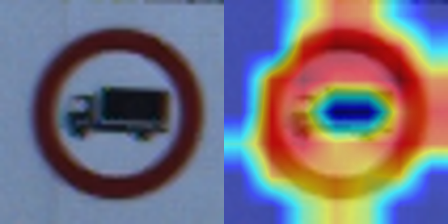

In [19]:
# Run benchmark for test image 00000
print_heatmap(cam, swin_model, device, "../data/Test/00000.png", 16, target_layers)

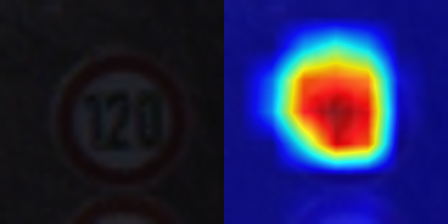

In [20]:
# Removed duplicate code; now using run_benchmark
print_heatmap(cam, swin_model, device, "../data/Test/00189.png", 8, target_layers)

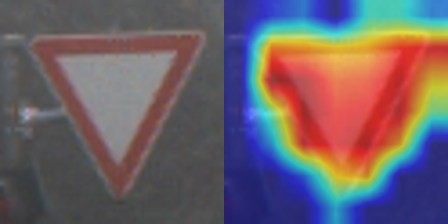

In [21]:
# Removed duplicate code; now using run_benchmark
print_heatmap(cam, swin_model, device, "../data/Test/00652.png", 13, target_layers)